In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
chickwts = pd.read_csv("../Datasets/chickwts.csv")

In [5]:
chickwts.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [6]:
chickwts.tail()

,weight,feed
66,359,casein
67,216,casein
68,222,casein
69,283,casein
70,332,casein


In [7]:
chickwts.shape

(71, 2)

In [9]:
chickwts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


In [13]:
chickwts.describe()

,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000


In [10]:
#missing values
chickwts.isnull().sum()

weight    0
feed      0
dtype: int64

In [11]:
#checking the types of feeds
chickwts['feed'].unique()

array(['horsebean', 'linseed', 'soybean', 'sunflower', 'meatmeal',
       'casein'], dtype=object)

In [12]:
#checking how many chickens received each feed
chickwts['feed'].value_counts()

feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64

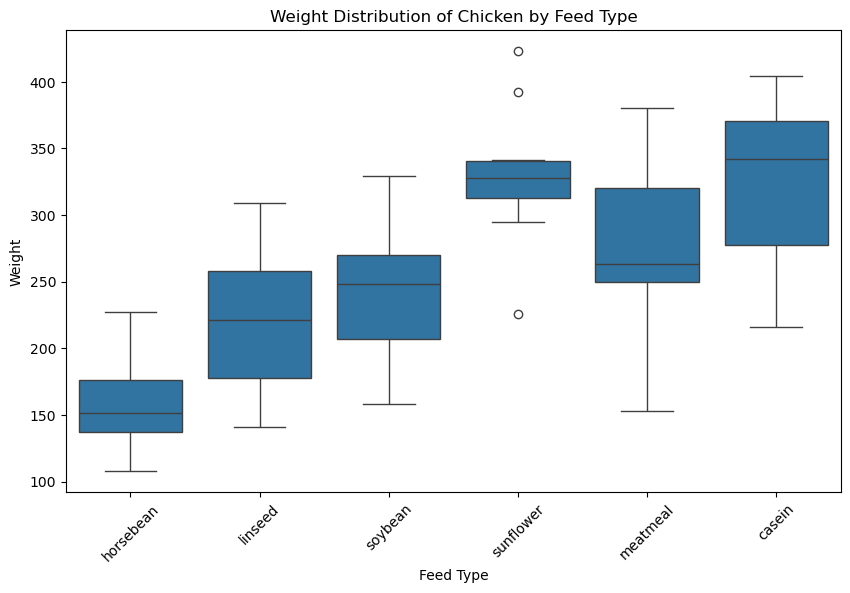

In [14]:
#visualization
plt.figure(figsize=(10,6))
sns.boxplot(data=chickwts,x='feed',y='weight')
plt.title('Weight Distribution of Chicken by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.show()

In [33]:
#calculating average weight for all feeds
average_weight = chickwts.groupby('feed', as_index=False)['weight'].mean()
average_weight

,feed,weight
0,casein,323.583333
1,horsebean,160.200000
2,linseed,218.750000
3,meatmeal,276.909091
4,soybean,246.428571
5,sunflower,328.916667


In [35]:
#standardizing the weight
scaler = StandardScaler()
average_weight['weight_scaled'] = scaler.fit_transform(average_weight[['weight']])
average_weight

,feed,weight,weight_scaled
0,casein,323.583333,1.091532
1,horsebean,160.200000,-1.675457
2,linseed,218.750000,-0.683880
3,meatmeal,276.909091,0.301077
4,soybean,246.428571,-0.215128
5,sunflower,328.916667,1.181855


In [38]:
#PCA 
pca=PCA(n_components=1)
pca_result=pca.fit_transform(average_weight[['weight_scaled']])

average_weight['PC1']=pca_result
average_weight

,feed,weight,weight_scaled,PC1
0,casein,323.583333,1.091532,1.091532
1,horsebean,160.200000,-1.675457,-1.675457
2,linseed,218.750000,-0.683880,-0.683880
3,meatmeal,276.909091,0.301077,0.301077
4,soybean,246.428571,-0.215128,-0.215128
5,sunflower,328.916667,1.181855,1.181855


In [39]:
pca.explained_variance_ratio_

array([1.])

In [69]:
#computing cosine similarity
pca_features=average_weight[['PC1']]
similarity_matrix=cosine_similarity(pca_features)
similarity_df = pd.DataFrame(similarity_matrix,
                             index=average_weight['feed'],
                             columns=average_weight['feed'])
similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


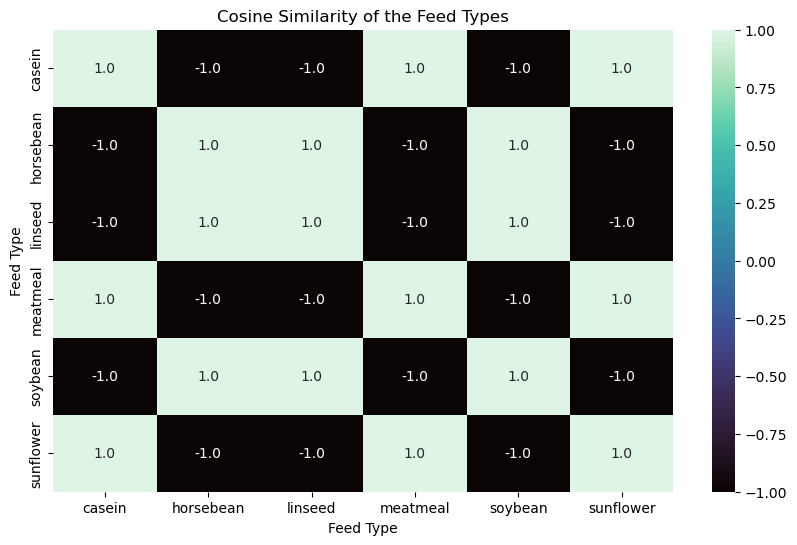

In [70]:
#cosine similarity heatmap
plt.figure(figsize=(10,6))
sns.heatmap(similarity_df, annot=True,cmap='mako',fmt='.1f')
plt.title('Cosine Similarity of the Feed Types')
plt.xlabel('Feed Type')
plt.ylabel('Feed Type')
plt.show()

In [68]:
#creating a recommendation function
def recommend_feeds(feed_name,similarity_df, n=3):
    similarities=similarity_df[feed_name].drop(feed_name)
    recommendations=similarities.sort_values(
    ascending=False).head(n)
    return recommendations

In [63]:
#testing the feeds
recommend_feeds('casein',similarity_df)

feed
meatmeal     1.0
sunflower    1.0
horsebean   -1.0
Name: casein, dtype: float64

In [62]:
recommend_feeds('meatmeal',similarity_df)

feed
casein       1.0
sunflower    1.0
horsebean   -1.0
Name: meatmeal, dtype: float64

In [61]:
recommend_feeds('sunflower',similarity_df)

feed
casein       1.0
meatmeal     1.0
horsebean   -1.0
Name: sunflower, dtype: float64

In [64]:
recommend_feeds('horsebean',similarity_df)

feed
linseed    1.0
soybean    1.0
casein    -1.0
Name: horsebean, dtype: float64

In [71]:
recommend_feeds('linseed',similarity_df)

feed
horsebean    1.0
soybean      1.0
casein      -1.0
Name: linseed, dtype: float64

In [72]:
recommend_feeds('soybean',similarity_df)

feed
horsebean    1.0
linseed      1.0
casein      -1.0
Name: soybean, dtype: float64